# INSTITUTO TECNOLÓGICO Y DE ESTUDIOS SUPERIORES DE MONTERREY

**Avance 5. Modelo Final**

Sistema de visión computacional para conteo e identificación de cajas en pallets

Proyecto Integrador (Gpo 10) Equipo #37 - Almacenes

Profesores Titulares: Dra. Grettel Barceló Alonso Dr. Luis Falcón Dra. Maria de la Paz Rico Dr. Jesús Camacho González

# Integrantes:

* Alan Camerino Cortés Cruz - A01167072

* Josué Daniel Lescano López - A01367234

* Ariel Mora Monroy - A01795561


Domingo 1 de marzo de 2026

# Objetivo

Clasificar el tipo de producto contenido en cajas dentro de un entorno de almacén utilizando el enfoque No Time To Train (NTTT). Este método permite aprovechar modelos de visión por computadora preentrenados para reconocer categorías visuales sin necesidad de realizar un proceso de entrenamiento adicional, lo que resulta especialmente útil cuando se dispone de pocos datos etiquetados o se requiere una solución rápida de implementar.

# Marco teórico

Hemos decidido usar el siguiente enfoque con No Time To Train se basa en el uso de modelos fundacionales previamente entrenados con grandes conjuntos de imágenes. En lugar de ajustar nuevamente los parámetros del modelo para una tarea específica, se utilizan directamente las representaciones visuales que este ya ha aprendido para comparar y clasificar nuevas imágenes. Estas representaciones capturan características relevantes como formas, texturas y patrones visuales, lo que permite distinguir entre distintos tipos de objetos incluso si el modelo no fue entrenado explícitamente para esa categoría.

Este tipo de metodología nos resulta particularmente útil para nuestra aplicación, donde la disponibilidad de datos etiquetados suele ser limitada y los objetos pueden presentar variaciones en tamaño, empaque o apariencia. Al evitar el entrenamiento, también se reduce significativamente el costo computacional y el tiempo de desarrollo, facilitando la creación de prototipos funcionales en etapas tempranas de un proyecto.

No obstante, el desempeño del método depende en gran medida de la calidad de las imágenes y de qué tan representativas sean respecto a los ejemplos implícitos en el preentrenamiento del modelo. Cambios en iluminación, ángulo de captura u oclusiones pueden afectar la similitud visual y, por lo tanto, la precisión de la clasificación.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!git clone https://github.com/miquel-espinosa/no-time-to-train.git

%cd no-time-to-train
!pip install -e .
%cd dinov2
!pip install -e .
%cd /content

In [ ]:
!pip install mmengine
!pip install -U pytorch_lightning==2.1.0
!pip install tidecv
!pip install pot
!pip install -U 'jsonargparse[signatures]==4.35.0'
!pip install segment_anything

In [ ]:
import pytorch_lightning as pl
import jsonargparse

print(f"PyTorch Lightning Version: {pl.__version__}") # tested on 2.1.0
print(f"jsonargparse Version: {jsonargparse.__version__}") # tested on 4.35.0

PyTorch Lightning Version: 2.1.0
jsonargparse Version: 4.35.0


In [ ]:
%mkdir -p checkpoints/dinov2
%cd checkpoints
!wget https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt
%cd dinov2
!wget https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth
%cd /content

/content/checkpoints
--2026-03-02 03:16:17--  https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.8.76.89, 65.8.76.35, 65.8.76.47, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.8.76.89|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 897952466 (856M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2_hiera_large.pt’

sam2_hiera_large.pt 100%[===================>] 856.35M   327MB/s    in 2.6s    

2026-03-02 03:16:20 (327 MB/s) - ‘sam2_hiera_large.pt’ saved [897952466/897952466]

/content/checkpoints/dinov2
--2026-03-02 03:16:20--  https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.8.76.89, 65.8.76.35, 65.8.76.47, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.8.76.89|:443... connected.
HTTP request sent, awaiting response... 200 OK
Leng

In [ ]:
!rm -rf /content/data/
print("Removed existing /content/data directory.")

Removed existing /content/data directory.


In [ ]:
# Test no-time-to-train custom dataset

#import os

# Create a data directory to store the annotations
!mkdir -p data/coco
!unzip /content/drive/MyDrive/MNA/annotations_trainval2017.zip -d /content/data/coco
#!unzip /content/drive/MyDrive/MNA/train2017.zip -d /content/data/coco
#!unzip /content/drive/MyDrive/MNA/val2017.zip -d /content/data/coco

#!mkdir -p data/my_custom_dataset
#!python /content/drive/MyDrive/MNA/no-time-to-train/scripts/make_custom_dataset.py

Archive:  /content/drive/MyDrive/MNA/annotations_trainval2017.zip
  inflating: /content/data/coco/annotations/instances_train2017.json  
  inflating: /content/data/coco/annotations/instances_val2017.json  
  inflating: /content/data/coco/annotations/captions_train2017.json  
  inflating: /content/data/coco/annotations/captions_val2017.json  
  inflating: /content/data/coco/annotations/person_keypoints_train2017.json  
  inflating: /content/data/coco/annotations/person_keypoints_val2017.json  


In [ ]:
import os

# Create the necessary directory structures
!mkdir -p /content/data/my_custom_dataset/images
!mkdir -p /content/data/my_custom_dataset/annotations
print("Created new directory structures: /content/data/my_custom_dataset/images and /content/data/my_custom_dataset/annotations.")

Created new directory structures: /content/data/my_custom_dataset/images and /content/data/my_custom_dataset/annotations.


In [ ]:
!
!cp /content/drive/MyDrive/MNA/shipping-box-detection-multi.coco/train/*.jpg /content/data/my_custom_dataset/images
!cp /content/drive/MyDrive/MNA/shipping-box-detection-multi.coco/train/_annotations.coco.json /content/data/my_custom_dataset/annotations/all_annotations.json

print("Images and annotation file copied successfully.")

Images and annotation file copied successfully.


In [ ]:
# Convert bbox coordinates from string to float
import json

annotations_file = 'data/my_custom_dataset/annotations/all_annotations.json'

with open(annotations_file, 'r') as f:
    data = json.load(f)

# Iterate through annotations and convert bbox coordinates to float
for annotation in data['annotations']:
    if 'bbox' in annotation and isinstance(annotation['bbox'], list):
        # Ensure all elements in bbox are converted to float
        annotation['bbox'] = [float(coord) for coord in annotation['bbox']]

with open(annotations_file, 'w') as f:
    json.dump(data, f, indent=4)

print(f"Successfully converted bbox coordinates to float and updated {annotations_file}")

Successfully converted bbox coordinates to float and updated data/my_custom_dataset/annotations/all_annotations.json


# Generate my own custom dataset

Se realiza una selección y reorganización de un dataset anotado en formato COCO para construir un subconjunto personalizado con clases de interés específicas. Este tipo de preprocesamiento permite trabajar únicamente con los datos relevantes, reducir ruido y facilitar tareas posteriores como detección, clasificación o evaluación de modelos.

Además, el script genera visualizaciones de las cajas delimitadoras sobre las imágenes para verificar que las anotaciones sean correctas, lo cual ayuda a detectar posibles errores o inconsistencias. Finalmente, generamos dos archivos JSON, uno con imágenes de referencia anotadas y otro con imágenes objetivo, manteniendo la estructura COCO. Esta separación resulta útil en métodos que comparan ejemplos conocidos con nuevas imágenes, como enfoques de reconocimiento basados en similitud o aprendizaje con pocos datos.

In [ ]:
import os
import json
import requests
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# --- CONFIGURATION ---
annotation_file = 'data/my_custom_dataset/annotations/all_annotations.json'
output_folder = 'data/my_custom_dataset'

selection = {
    "reference": {
        # "a small cardboard shipping box":[9, 10]
        "fresa": [1, 2, 3],
        "mazapan": [1, 2, 3],
        "relleno": [1, 2, 3]
    },
    "targets": [9, 10]
}

# --- CREATE OUTPUT FOLDERS ---
images_dir = os.path.join(output_folder, "images")
annotations_dir = os.path.join(output_folder, "annotations")
vis_dir = os.path.join(annotations_dir, "references_visualisations")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(annotations_dir, exist_ok=True)
os.makedirs(vis_dir, exist_ok=True)

# --- LOAD COCO DATA ---
coco = COCO(annotation_file)
category_name_to_id = {cat['name']: cat['id'] for cat in coco.loadCats(coco.getCatIds())}

# --- PROCESS REFERENCES ---
new_images = []
new_annotations = []
new_categories = []
used_category_ids = set()
used_image_ids = set()
new_ann_id = 1

for class_name, image_ids_for_class in selection["reference"].items(): # Renamed to avoid confusion with imgIds for coco
    cat_id = category_name_to_id[class_name]
    for image_idx, image_id in enumerate(image_ids_for_class): # Use image_idx for unique filenames
        ann_ids = coco.getAnnIds(imgIds=image_id, catIds=cat_id)
        anns = coco.loadAnns(ann_ids)

        if not anns:
            continue

        img_info = coco.loadImgs(image_id)[0]

        # Only add image info if it hasn't been added yet (to avoid duplicates for multi-category images)
        if image_id not in used_image_ids:
            new_images.append(img_info)
            used_image_ids.add(image_id)

        for ann in anns:
            ann_copy = ann.copy()  # Make sure we don't modify the original COCO dict
            ann_copy.pop("segmentation", None)  # Remove segmentation if present
            ann_copy['id'] = new_ann_id
            new_ann_id += 1
            new_annotations.append(ann_copy)

        used_category_ids.add(cat_id)

        # --- Visualisation ---
        # Load image
        img_path = os.path.join(images_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")

        # Create plot
        fig, ax = plt.subplots(1)
        ax.imshow(image)

        for ann_item in anns: # Use ann_item to avoid conflict with outer loop variable
            bbox = ann_item['bbox']
            rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3],
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

        vis_path = os.path.join(vis_dir, f"{class_name}_{img_info['file_name']}") # Use image filename for unique vis name
        ax.axis('off') # Turn off axes for a cleaner image
        plt.savefig(vis_path, bbox_inches='tight', pad_inches=0)
        plt.close(fig) # Close the figure to free up memory

# --- INCLUDE USED CATEGORIES ---
# Ensure categories are unique
new_categories = [cat for cat in coco.loadCats(list(used_category_ids))]

# --- SAVE NEW ANNOTATIONS ---
custom_json = {
    "images": new_images,
    "annotations": new_annotations,
    "categories": new_categories
}

with open(os.path.join(annotations_dir, "custom_references.json"), 'w') as f:
    json.dump(custom_json, f)

# --- SAVE TARGET IMAGES WITHOUT ANNOTATIONS ---
target_images = []
for image_id in selection["targets"]:
    img_info = coco.loadImgs(image_id)[0]
    if img_info not in target_images: # Avoid duplicate image entries
        target_images.append(img_info)

target_annotations = []
for image_id in selection["targets"]:
    ann_ids = coco.getAnnIds(imgIds=image_id)
    anns = coco.loadAnns(ann_ids)
    target_annotations.extend(anns)

custom_targets_json = {
    "images": target_images,
    "annotations": target_annotations,
    "categories": new_categories  # Optional, but keeps category info consistent
}

with open(os.path.join(annotations_dir, "custom_targets.json"), 'w') as f:
    json.dump(custom_targets_json, f)

print(f"✅ Saved annotations to {annotations_dir}/custom_references.json")
print(f"✅ Saved target-only metadata to {annotations_dir}/custom_targets.json")
print(f"✅ Visualisations saved in {vis_dir}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Saved annotations to data/my_custom_dataset/annotations/custom_references.json
✅ Saved target-only metadata to data/my_custom_dataset/annotations/custom_targets.json
✅ Visualisations saved in data/my_custom_dataset/annotations/references_visualisations


In [ ]:
import json
import random
import os

input_json_path = 'data/my_custom_dataset/annotations/custom_references.json'
output_json_path = 'data/my_custom_dataset/annotations/custom_references_50shot.json'
SHOT_TARGET = 50

print(f"Loading annotations from: {input_json_path}")
with open(input_json_path, 'r') as f:
    data = json.load(f)

images = data['images']
categories = data['categories']
annotations = data['annotations']

# Group annotations by category_id
annotations_by_category = {}
for cat in categories:
    annotations_by_category[cat['id']] = []

for ann in annotations:
    if ann['category_id'] in annotations_by_category:
        annotations_by_category[ann['category_id']].append(ann)

modified_annotations = []
new_ann_id_counter = 1

# Process each category
for cat_id, ann_list in annotations_by_category.items():
    if not ann_list: # Skip if no annotations for this category
        print(f"Warning: No annotations found for category {cat_id}. Skipping duplication/sampling.")
        continue

    final_ann_for_category = []
    if len(ann_list) < SHOT_TARGET:
        # Duplicate annotations to reach SHOT_TARGET
        num_to_duplicate = SHOT_TARGET - len(ann_list)
        # Use random.choices for sampling with replacement
        duplicated_ann = random.choices(ann_list, k=num_to_duplicate)
        final_ann_for_category.extend(ann_list)
        final_ann_for_category.extend(duplicated_ann)
        print(f"Category {cat_id} had {len(ann_list)} references, duplicated to {len(final_ann_for_category)}.")
    elif len(ann_list) > SHOT_TARGET:
        # Randomly sample SHOT_TARGET annotations
        final_ann_for_category = random.sample(ann_list, k=SHOT_TARGET)
        print(f"Category {cat_id} had {len(ann_list)} references, sampled down to {len(final_ann_for_category)}.")
    else:
        final_ann_for_category = ann_list
        print(f"Category {cat_id} had {len(ann_list)} references, no change needed.")

    # Assign new unique IDs to all annotations in this category
    for ann in final_ann_for_category:
        ann_copy = ann.copy()
        ann_copy['id'] = new_ann_id_counter
        modified_annotations.append(ann_copy)
        new_ann_id_counter += 1

# Create the new JSON structure
new_json_data = {
    'images': images,
    'annotations': modified_annotations,
    'categories': categories
}

# Save the modified data to the new file
print(f"Saving modified annotations to: {output_json_path}")
with open(output_json_path, 'w') as f:
    json.dump(new_json_data, f, indent=4)

print("Process complete. The new JSON file has been created.")

Loading annotations from: data/my_custom_dataset/annotations/custom_references.json
Category 2 had 22 references, duplicated to 50.
Category 3 had 50 references, no change needed.
Category 4 had 4 references, duplicated to 50.
Saving modified annotations to: data/my_custom_dataset/annotations/custom_references_50shot.json
Process complete. The new JSON file has been created.


In [ ]:
import json
import random
import os

input_json_path = 'data/my_custom_dataset/annotations/custom_references.json'
output_json_path = 'data/my_custom_dataset/annotations/custom_references_4shot.json'
SHOT_TARGET = 4 # Set the target number of shots to 4

print(f"Loading annotations from: {input_json_path}")
with open(input_json_path, 'r') as f:
    data = json.load(f)

images = data['images']
categories = data['categories']
annotations = data['annotations']

# Group annotations by category_id
annotations_by_category = {}
for cat in categories:
    annotations_by_category[cat['id']] = []

for ann in annotations:
    if ann['category_id'] in annotations_by_category:
        annotations_by_category[ann['category_id']].append(ann)

modified_annotations = []
new_ann_id_counter = 1

# Process each category
for cat_id, ann_list in annotations_by_category.items():
    if not ann_list: # Skip if no annotations for this category
        print(f"Warning: No annotations found for category {cat_id}. Skipping duplication/sampling.")
        continue

    final_ann_for_category = []
    if len(ann_list) < SHOT_TARGET:
        # Duplicate annotations to reach SHOT_TARGET
        num_to_duplicate = SHOT_TARGET - len(ann_list)
        # Use random.choices for sampling with replacement
        duplicated_ann = random.choices(ann_list, k=num_to_duplicate)
        final_ann_for_category.extend(ann_list)
        final_ann_for_category.extend(duplicated_ann)
        print(f"Category {cat_id} had {len(ann_list)} references, duplicated to {len(final_ann_for_category)}.")
    elif len(ann_list) > SHOT_TARGET:
        # Randomly sample SHOT_TARGET annotations
        final_ann_for_category = random.sample(ann_list, k=SHOT_TARGET)
        print(f"Category {cat_id} had {len(ann_list)} references, sampled down to {len(final_ann_for_category)}.")
    else:
        final_ann_for_category = ann_list
        print(f"Category {cat_id} had {len(ann_list)} references, no change needed.")

    # Assign new unique IDs to all annotations in this category
    for ann in final_ann_for_category:
        ann_copy = ann.copy()
        ann_copy['id'] = new_ann_id_counter
        modified_annotations.append(ann_copy)
        new_ann_id_counter += 1

# Create the new JSON structure
new_json_data = {
    'images': images,
    'annotations': modified_annotations,
    'categories': categories
}

# Save the modified data to the new file
print(f"Saving modified annotations to: {output_json_path}")
with open(output_json_path, 'w') as f:
    json.dump(new_json_data, f, indent=4)

print("Process complete. The new JSON file has been created.")

Loading annotations from: data/my_custom_dataset/annotations/custom_references.json
Category 2 had 22 references, sampled down to 4.
Category 3 had 50 references, sampled down to 4.
Category 4 had 4 references, no change needed.
Saving modified annotations to: data/my_custom_dataset/annotations/custom_references_4shot.json
Process complete. The new JSON file has been created.


In [ ]:
# Download sam_h checkpoint. Feel free to use more recent checkpoints (note: code might need to be adapted)
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O checkpoints/sam_vit_h_4b8939.pth

--2026-03-02 03:20:13--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.8.76.35, 65.8.76.89, 65.8.76.77, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.8.76.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘checkpoints/sam_vit_h_4b8939.pth’

checkpoints/sam_vit 100%[===================>]   2.39G   364MB/s    in 7.3s    

2026-03-02 03:20:20 (334 MB/s) - ‘checkpoints/sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
# Run automatic instance segmentation from ground truth bounding boxes.
!python no-time-to-train/no_time_to_train/dataset/sam_bbox_to_segm_batch.py \
    --input_json data/my_custom_dataset/annotations/custom_references_4shot.json \
    --image_dir data/my_custom_dataset/images \
    --sam_checkpoint checkpoints/sam_vit_h_4b8939.pth \
    --model_type vit_h \
    --device cuda \
    --batch_size 8 \
    --visualize

Number of images without any annotations: 0
Processing images: 100% 3/3 [00:10<00:00,  3.60s/it]


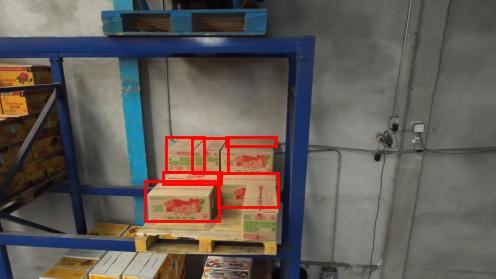

In [ ]:
from IPython.display import Image
Image(filename='/content/data/my_custom_dataset/annotations/references_visualisations/fresa_00000.jpg')

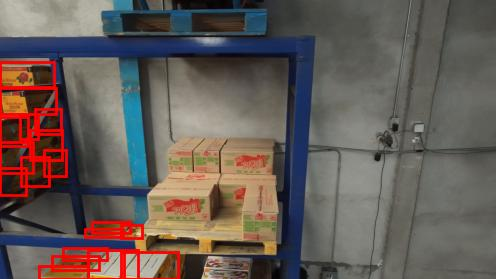

In [ ]:
Image(filename='/content/data/my_custom_dataset/annotations/references_visualisations/mazapan_00000.jpg')

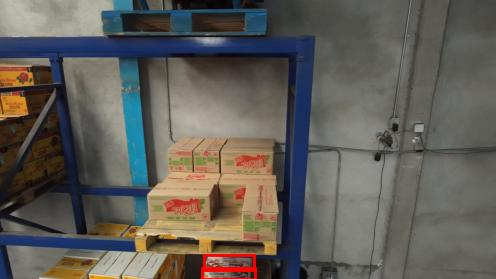

In [ ]:
Image(filename='/content/data/my_custom_dataset/annotations/references_visualisations/relleno_00000.jpg')

In [ ]:
!python no-time-to-train/no_time_to_train/dataset/coco_to_pkl.py \
    data/my_custom_dataset/annotations/custom_references_4shot_with_segm.json \
    data/my_custom_dataset/annotations/custom_references_4shot_with_segm.pkl \
    1

Converted data written to data/my_custom_dataset/annotations/custom_references_4shot_with_segm.pkl


In [ ]:
# Generar segmentaciones para anotaciones objetivo
!
!python no-time-to-train/no_time_to_train/dataset/sam_bbox_to_segm_batch.py \
    --input_json data/my_custom_dataset/annotations/custom_targets.json \
    --output_json data/my_custom_dataset/annotations/custom_targets_with_segm.json \
    --image_dir data/my_custom_dataset/images \
    --sam_checkpoint checkpoints/sam_vit_h_4b8939.pth \
    --model_type vit_h \
    --device cuda \
    --batch_size 8 \
    --visualize

Number of images without any annotations: 0
Processing images:  50% 1/2 [00:18<00:18, 18.50s/it]Warning: Invalid polygon when generating segmentation mask - Skipping
Processing images: 100% 2/2 [00:54<00:00, 27.23s/it]


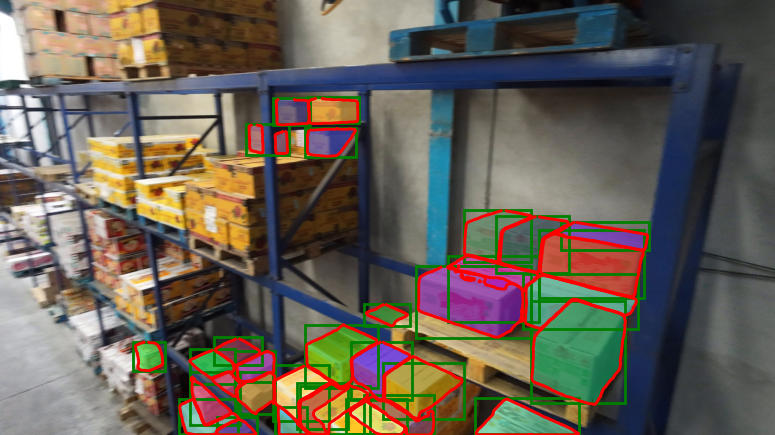

In [ ]:
Image(filename='/content/data/my_custom_dataset/annotations/custom_targets_with_SAM_segm/00004_segm.png')

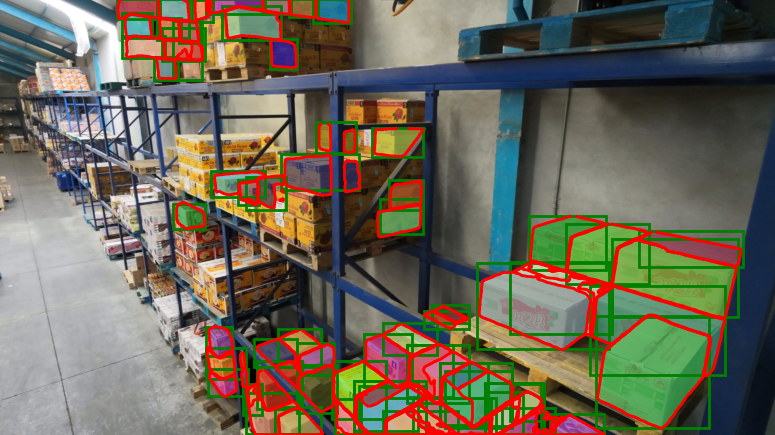

In [ ]:
Image(filename='/content/data/my_custom_dataset/annotations/custom_targets_with_SAM_segm/00005_segm.png')

# Execute no-time-to-train steps

In [ ]:
DATASET_NAME='my_custom_dataset'
DATASET_PATH='data/my_custom_dataset'
CAT_NAMES='fresa', 'mazapan', 'relleno'
CATEGORY_NUM=3
SHOT=4    #
YAML_PATH='no-time-to-train/no_time_to_train/pl_configs/matching_cdfsod_template.yaml'
PATH_TO_SAVE_CKPTS='./tmp_ckpts/my_custom_dataset'
!mkdir -p {PATH_TO_SAVE_CKPTS}

In [ ]:
!python /content/no-time-to-train/run_lightening.py test --config {YAML_PATH} \
    --model.test_mode fill_memory \
    --out_path {PATH_TO_SAVE_CKPTS}/{DATASET_NAME}_{SHOT}_refs_memory.pth \
    --model.init_args.dataset_cfgs.fill_memory.root {DATASET_PATH}/images \
    --model.init_args.dataset_cfgs.fill_memory.json_file {DATASET_PATH}/annotations/custom_references_4shot_with_segm.json \
    --model.init_args.dataset_cfgs.fill_memory.memory_pkl {DATASET_PATH}/annotations/custom_references_4shot_with_segm.pkl \
    --model.init_args.dataset_cfgs.fill_memory.memory_length {SHOT} \
    --model.init_args.dataset_cfgs.fill_memory.cat_names "{','.join(CAT_NAMES)}" \
    --model.init_args.model_cfg.dataset_name {DATASET_NAME} \
    --model.init_args.model_cfg.memory_bank_cfg.length {SHOT} \
    --model.init_args.model_cfg.memory_bank_cfg.category_num {CATEGORY_NUM} \
    --trainer.devices 1

2026-03-02 04:52:04.481882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772427124.504650   32882 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772427124.512298   32882 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772427124.531540   32882 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427124.531571   32882 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427124.531575   32882 computation_placer.cc:177] computation placer alr

In [ ]:
# set `torch.set_float32_matmul_precision('high')` to leverage the Tensor Cores of your GPU for improved performance.
# You can change it to `'medium'` if you need a balance between precision and speed, or remove it if you need full precision.
import torch
torch.set_float32_matmul_precision('high')

In [ ]:
!python no-time-to-train/run_lightening.py test --config {YAML_PATH} \
    --model.test_mode postprocess_memory \
    --ckpt_path {PATH_TO_SAVE_CKPTS}/{DATASET_NAME}_{SHOT}_refs_memory.pth \
    --out_path $PATH_TO_SAVE_CKPTS/{DATASET_NAME}_{SHOT}_refs_memory_postprocessed.pth \
    --model.init_args.model_cfg.dataset_name {DATASET_NAME} \
    --model.init_args.model_cfg.memory_bank_cfg.length {SHOT} \
    --model.init_args.model_cfg.memory_bank_cfg.category_num {CATEGORY_NUM} \
    --trainer.devices 1

2026-03-02 04:53:23.658157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772427203.680791   33294 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772427203.688208   33294 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772427203.706968   33294 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427203.706995   33294 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427203.706997   33294 computation_placer.cc:177] computation placer alr

In [ ]:
!rm -rf /content/results_analysis
print("Removed existing /content/results_analysis directory.")

Removed existing /content/results_analysis directory.


In [ ]:
!python no-time-to-train/run_lightening.py test --config {YAML_PATH} \
    --model.test_mode vis_memory \
    --ckpt_path {PATH_TO_SAVE_CKPTS}/{DATASET_NAME}_{SHOT}_refs_memory_postprocessed.pth \
    --model.init_args.dataset_cfgs.fill_memory.root {DATASET_PATH}/images \
    --model.init_args.dataset_cfgs.fill_memory.json_file {DATASET_PATH}/annotations/custom_references_4shot_with_segm.json \
    --model.init_args.dataset_cfgs.fill_memory.memory_pkl {DATASET_PATH}/annotations/custom_references_4shot_with_segm.pkl \
    --model.init_args.dataset_cfgs.fill_memory.memory_length {SHOT} \
    --model.init_args.dataset_cfgs.fill_memory.cat_names "{','.join(CAT_NAMES)}" \
    --model.init_args.model_cfg.dataset_name {DATASET_NAME} \
    --model.init_args.model_cfg.memory_bank_cfg.length {SHOT} \
    --model.init_args.model_cfg.memory_bank_cfg.category_num {CATEGORY_NUM} \
    --trainer.devices 1

2026-03-02 04:55:41.247015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772427341.269670   33994 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772427341.277157   33994 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772427341.296833   33994 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427341.296860   33994 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427341.296863   33994 computation_placer.cc:177] computation placer alr

Para mostrar de forma organizada se realiza un conjunto de imágenes en una cuadrícula, lo que permite revisarlas visualmente de manera rápida y comparativa. Este tipo de visualización se utiliza comúnmente en visión por computadora para analizar datos o evaluar resultados de modelos, ya que facilita detectar patrones, errores o diferencias entre imágenes.

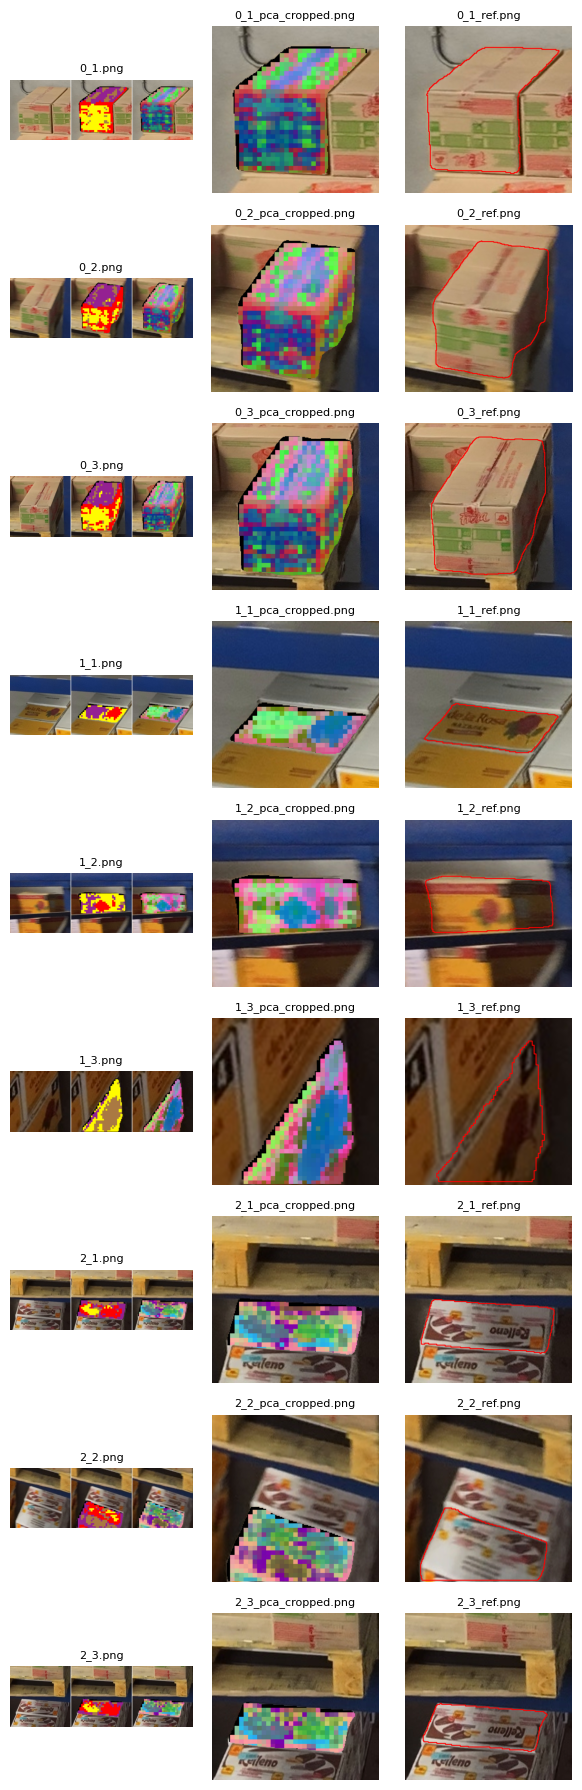

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = '/content/results_analysis/memory_vis/my_custom_dataset_dinov2_large'

# Get all image files in the directory
image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
image_files.sort() # Sort to ensure consistent order

if not image_files:
    print(f"No image files found in {image_dir}")
else:
    rows = 9
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()

    for i, img_path in enumerate(image_files):
        if i >= rows * cols:
            break
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, 'Error loading image', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
            axes[i].axis('off')
            print(f"Error loading {img_path}: {e}")

    # Turn off any remaining empty subplots
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
ONLINE_VIS=True
VIS_THR=0.6
!python no-time-to-train/run_lightening.py test --config {YAML_PATH} \
    --model.test_mode test \
    --ckpt_path {PATH_TO_SAVE_CKPTS}/{DATASET_NAME}_{SHOT}_refs_memory_postprocessed.pth \
    --model.init_args.model_cfg.dataset_name {DATASET_NAME} \
    --model.init_args.model_cfg.memory_bank_cfg.length {SHOT} \
    --model.init_args.model_cfg.memory_bank_cfg.category_num {CATEGORY_NUM} \
    --model.init_args.model_cfg.test.imgs_path {DATASET_PATH}/images \
    --model.init_args.model_cfg.test.online_vis {ONLINE_VIS} \
    --model.init_args.model_cfg.test.vis_thr {VIS_THR} \
    --model.init_args.dataset_cfgs.test.root {DATASET_PATH}/images \
    --model.init_args.dataset_cfgs.test.json_file {DATASET_PATH}/annotations/custom_targets_with_segm.json \
    --model.init_args.dataset_cfgs.test.cat_names "{','.join(CAT_NAMES)}" \
    --model.init_args.dataset_cfgs.test.batch_size 1 \
    --trainer.devices 1

2026-03-02 05:15:37.805666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772428537.829897   39507 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772428537.837377   39507 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772428537.856292   39507 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772428537.856323   39507 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772428537.856326   39507 computation_placer.cc:177] computation placer alr

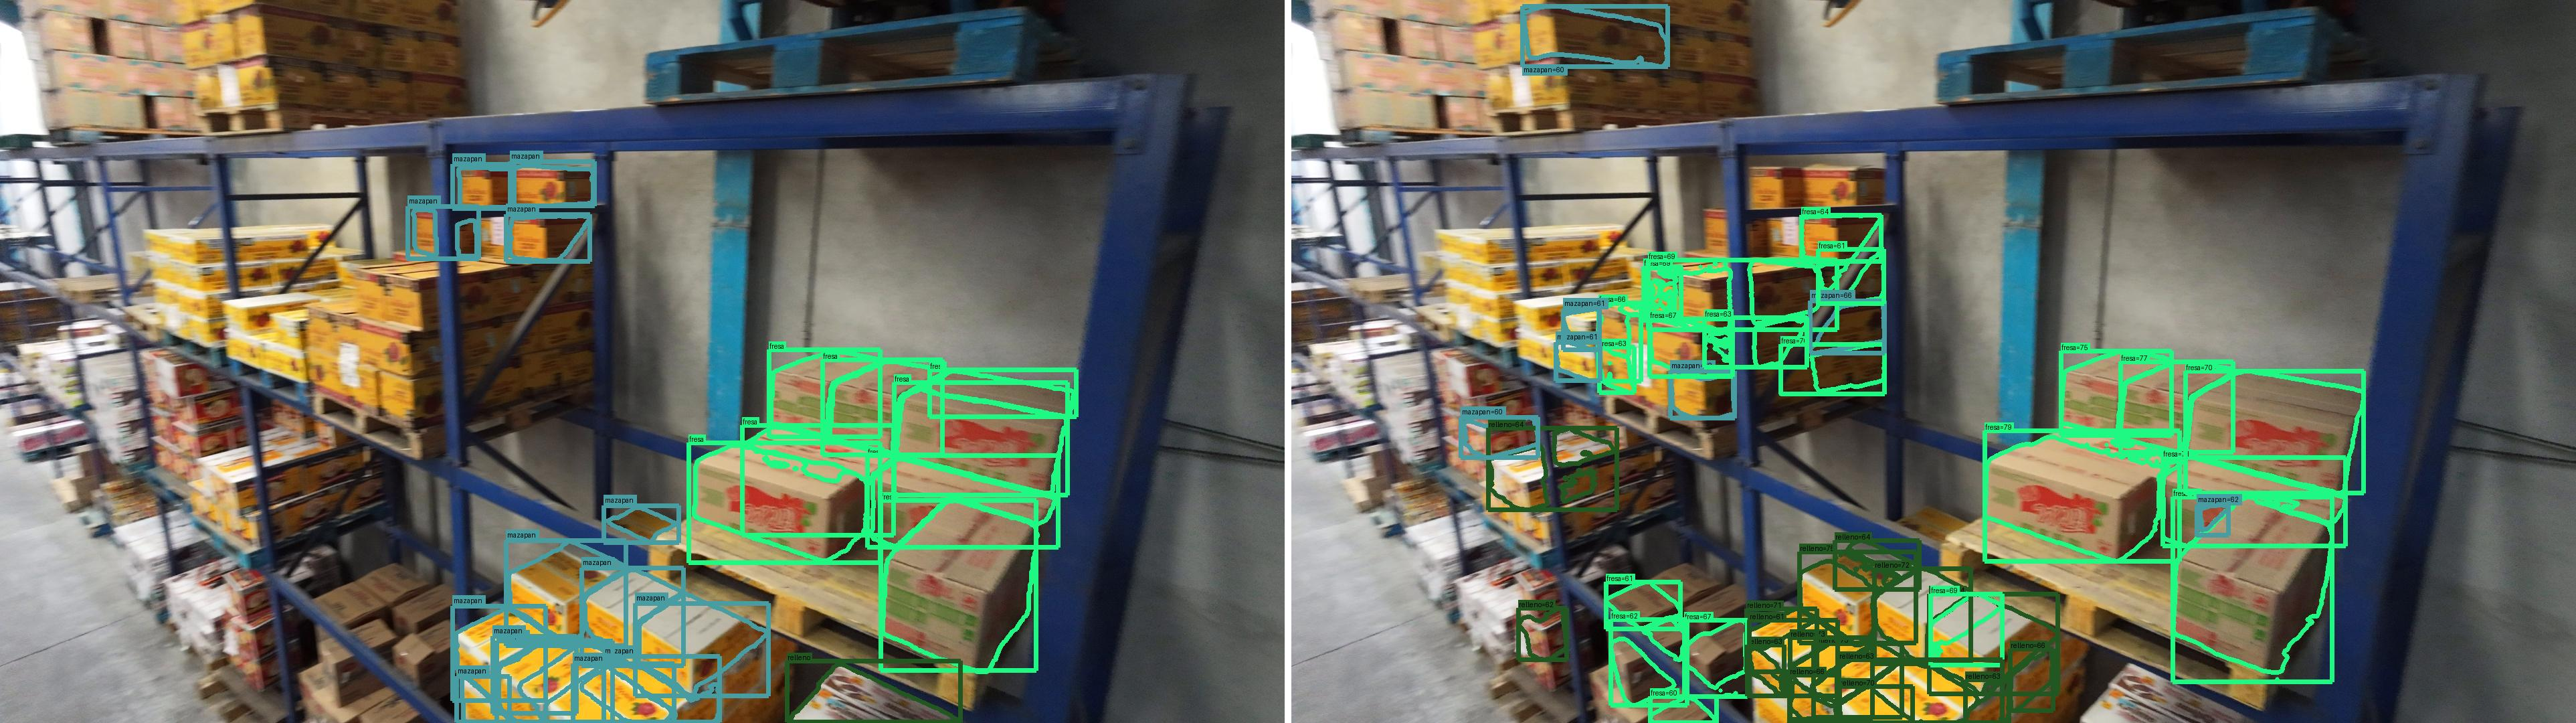

In [ ]:
from IPython.display import Image
Image(filename='/content/results_analysis/my_custom_dataset_dinov2_large/00004.jpg')

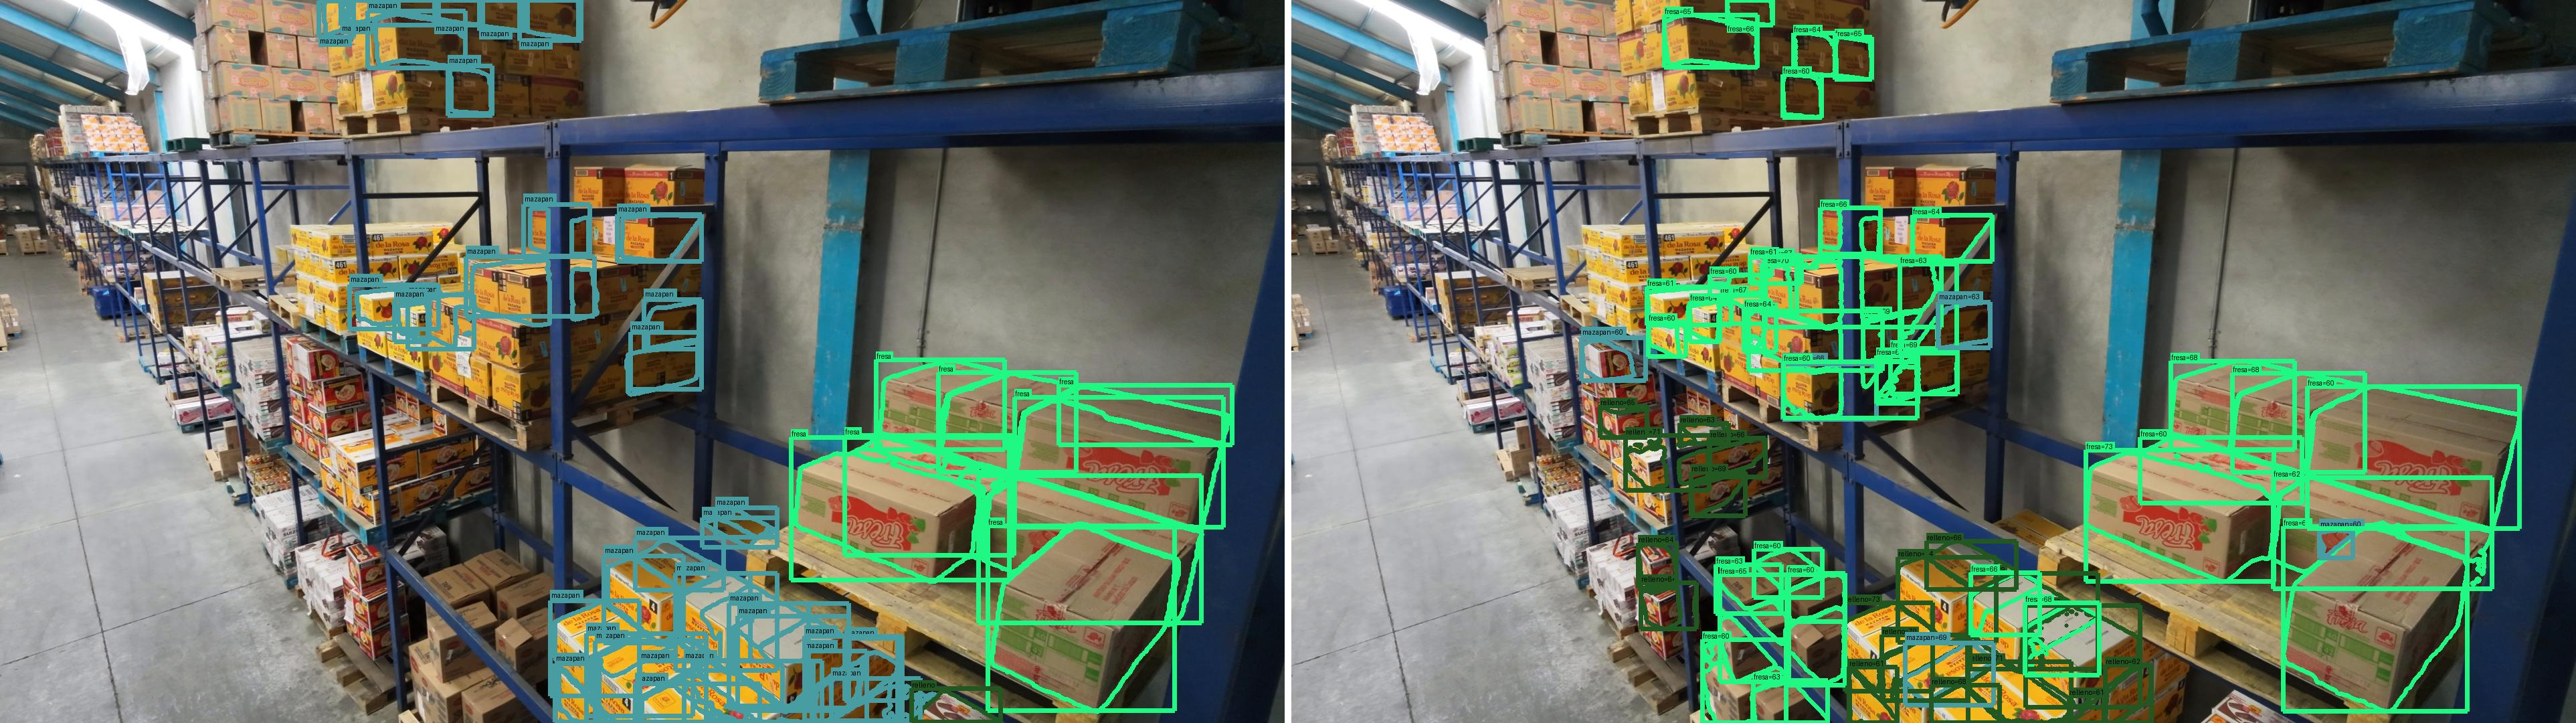

In [ ]:
Image(filename='/content/results_analysis/my_custom_dataset_dinov2_large/00005.jpg')

# Conclusiones

El uso del enfoque No Time To Train nos permitió realizar la clasificación de productos de manera eficiente sin necesidad de entrenar un modelo desde cero.Solo que en el uso de pocas imagenes que obtuvimos en las mismas imagenes, teniendo en cuenta la importancia de la calidad de las imagenes. Los resultados obtenidos muestran que las representaciones visuales de modelos preentrenados pueden ser suficientes para distinguir entre categorías de productos en condiciones relativamente controladas, lo que lo convierte en una alternativa práctica cuando el tiempo, los recursos o los datos disponibles son limitados.

Sin embargo, también se observaron limitaciones asociadas a variaciones visuales entre las imágenes, así como a posibles similitudes entre productos, lo que puede generar confusiones en la clasificación. Aun así, el método nos demuestra un equilibrio favorable entre simplicidad de implementación y desempeño, y representa una base sólida para sistemas de identificación automática en entornos logísticos. En escenarios reales, su efectividad puede incrementarse combinándolo con técnicas adicionales de filtrado, selección de imágenes o modelos especializados.

Por lo tanto, para trabajos futuros se ha determinado que será conveniente emplear una combinación de métodos que aporten una mayor comprensión semántica del entorno, así como técnicas de segmentación más robustas y precisas. La integración de distintos enfoques permitirá compensar las limitaciones observadas en cada uno de ellos de manera individual y mejorar tanto la detección como el análisis de los objetos presentes en la escena.